In [2]:
!pip install groq python-dotenv

## Conversational Engine

In [3]:
# setup

import os
from dotenv import load_dotenv
from groq import Groq

load_dotenv() 

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

response = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[{"role": "user", "content": "Say hello in one short sentence."}]
)

print(response.choices[0].message.content)

Hello!


In [4]:
from Clinical_Ontology import CHIEF_COMPLAINT_ONTOLOGY, STANDARD_HISTORY_SECTIONS

In [5]:
# conversation state

def detect_chief_complaint(patient_text):
    
    known_complaints = list(CHIEF_COMPLAINT_ONTOLOGY.keys())
    
    prompt = f"""The patient said: "{patient_text}"
    Which of these known complaints does this best match: "{known_complaints}"?
    Respond only with the matching category name from the list, or "unknown" if none fit. No Explaination, just the category name"""

    response = client.chat.completions.create(
        model = "openai/gpt-oss-120b",
        messages = [{"role": "user", "content": prompt}],
        temperature = 0
    )
    return response.choices[0].message.content.strip()

In [6]:
test_result = detect_chief_complaint("I've had really bad chest pain since morning")
print(test_result)

chest_pain


In [7]:
conversation_state = {
    "cheif_complaint": None,
    "current_section": "chief_complaint",
    "question_index": 0,
    "transcript": []
}

In [8]:
def get_next_question(state):
    
    if state["current_section"] == "chief_complaint":
        questions = CHIEF_COMPLAINT_ONTOLOGY[state["chief_complaint"]]["follow_up_questions"]
        
        if state["question_index"] < len(questions):
            return questions[state["question_index"]]
        else:
            state["current_section"] = "past_medical_surgical_history"
            state["question_index"] = 0
            return get_next_question(state)
    
    elif state["current_section"] in STANDARD_HISTORY_SECTIONS:
        questions = STANDARD_HISTORY_SECTIONS[state["current_section"]]
        
        if state["question_index"] < len(questions):
            return questions[state["question_index"]]
        else:
            section_order = list(STANDARD_HISTORY_SECTIONS.keys())
            current_idx = section_order.index(state["current_section"])
            
            if current_idx + 1 < len(section_order):
                state["current_section"] = section_order[current_idx + 1]
                state["question_index"] = 0
                return get_next_question(state)
            else:
                state["current_section"] = "done"
                return None
    
    return None

In [9]:
conversation_state["chief_complaint"] = "chest_pain"

q1 = get_next_question(conversation_state)
print(q1)

Where exactly is the pain located?


In [10]:
# the conversation loop

def run_history_intake(state):
    
    while state["current_section"] != "done":
        question = get_next_question(state)
        
        if question is None:
            break
        
        print(f"\nAI: {question}")
        answer = input("Patient: ")
        
        state["transcript"].append({
            "question": question,
            "answer": answer,
            "section": state["current_section"]
        })

        if state["current_section"] == "chief_complaint":
            flagged, flags = check_red_flag(state["chief_complaint"], answer)
            if flagged:
                state["flagged_red_flags"] = state.get("flagged_red_flags", [])
                state["flagged_red_flags"].append({"answer": answer, "matched_flags":flags})
                print(" ALERT : RED FLAG DETECTED - PATIENT WILL IMMEDIATELY NEED ASSISTANCE")
        
        state["question_index"] += 1
    
    print("\n✅ History intake complete.")

    if state.get("flagged_red_flags"):
        print(f"\n {len(state['flagged_red_flags'])}, red flags were detected")
    return state

In [13]:
def check_red_flag(chief_complaint, patient_answer):
    
    if chief_complaint not in CHIEF_COMPLAINT_ONTOLOGY:
        return False, None
    
    red_flags = CHIEF_COMPLAINT_ONTOLOGY[chief_complaint]["red_flags"]
    complaint_readable = chief_complaint.replace("_", " ")
    
    prompt = f"""A patient came in with a chief complaint of: {complaint_readable}.

During follow-up questioning, the patient just answered: "{patient_answer}"

Given that this patient has {complaint_readable}, does their answer suggest any of these red flag warning signs: {red_flags}?
Respond with ONLY "yes" or "no"."""
    
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    
    result = response.choices[0].message.content.strip().lower()
    is_flagged = "yes" in result
    
    return is_flagged, red_flags if is_flagged else None

In [42]:
conversation_state = {
    "chief_complaint": "chest_pain",
    "current_section": "chief_complaint",
    "question_index": 0,
    "transcript": []
}

final_state = run_history_intake(conversation_state)


AI: Where exactly is the pain located?


Patient:  in the center of my chest



AI: When did it start — suddenly or gradually?


Patient:  suddenly



AI: How would you describe the pain — sharp, dull, burning, cramping?


...


AI: Any joint pains, swelling, or skin issues?


Patient:  no



AI: Any recent changes in vision, hearing, or balance?


Patient:  no



✅ History intake complete.


In [43]:
flagged, flags = check_red_flag("chest_pain", "yes I'm sweating a lot and feel dizzy")
print(flagged, flags)

True ['chest pain with breathlessness', 'chest pain with sweating', 'chest pain radiating to arm or jaw', 'chest pain with fainting or dizziness']


In [44]:
# def check_red_flag_debug(chief_complaint, patient_answer):
#     red_flags = CHIEF_COMPLAINT_ONTOLOGY[chief_complaint]["red_flags"]

#     prompt = f"""Patient's answer: "{patient_answer}"

#     Does this answer suggest any of the red flag warning signs: "{red_flags}"?
#     Respond only with "yes" or "no". """

#     print("PROMPT SENT:\n", prompt)
#     print("\n---\n")

#     response = client.chat.completions.create(
#         model="openai/gpt-oss-120b",
#         messages=[{"role": "user", "content": prompt}],
#         temperature=0
#     )

#     raw_result = response.choices[0].message.content
#     print("RAW MODEL OUTPUT:", repr(raw_result))

#     return raw_result

# check_red_flag_debug("chest_pain", "yes, i'm sweating a lot and feeling dizzy")

## Document Digitization

In [45]:
sample_prescription_text = """
Dr. R. Sharma, MBBS, MD
City Hospital, Delhi
Date: 12/03/2025

Patient: Ramesh Kumar, Age: 45, M

Diagnosis: Type 2 Diabetes Mellitus, Hypertension

Rx:
1. Tab Metformin 500mg - 1-0-1 after food
2. Tab Amlodipine 5mg - 1-0-0 morning
3. Tab Atorvastatin 10mg - 0-0-1 at night

Investigations advised: HbA1c, Lipid Profile, Fasting Blood Sugar

Follow up after 2 weeks
"""

In [46]:
import json

def extract_document_data(raw_text):
    """Takes raw OCR text and extracts structured clinical data using the LLM."""
    
    prompt = f"""Below is text extracted from a scanned medical document (prescription/lab report).

                Extract the following information and return ONLY a valid JSON object with these exact keys:
                - "diagnosis": list of diagnoses mentioned (empty list if none)
                - "medications": list of objects, each with "name", "dosage", and "frequency" (empty list if none)
                - "investigations": list of tests/investigations advised or reported (empty list if none)
                - "date": the date on the document, if mentioned (null if not found)
                - "doctor_name": the doctor's name, if mentioned (null if not found)
                
                Document text:
                \"\"\"{raw_text}\"\"\"
                
                Return ONLY the JSON object, no other text, no markdown formatting, no explanation."""
    
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    
    raw_output = response.choices[0].message.content.strip()
    
    return raw_output

In [47]:
result = extract_document_data(sample_prescription_text)
print(result)

{"diagnosis":["Type 2 Diabetes Mellitus","Hypertension"],"medications":[{"name":"Metformin","dosage":"500mg","frequency":"1-0-1 after food"},{"name":"Amlodipine","dosage":"5mg","frequency":"1-0-0 morning"},{"name":"Atorvastatin","dosage":"10mg","frequency":"0-0-1 at night"}],"investigations":["HbA1c","Lipid Profile","Fasting Blood Sugar"],"date":"12/03/2025","doctor_name":"Dr. R. Sharma"}


In [48]:
import json

def parse_extracted_data(raw_output):
    try:
        cleaned = raw_output.strip()
        if cleaned.startswith("```"):
            cleaned = cleaned.split("```")[1]
            if cleaned.startswith("json"):
                cleaned = cleaned[4:]
        
        data = json.loads(cleaned)
        return data
    except json.JSONDecodeError as e:
        print(f"Failed to parse JSON: {e}")
        print(f"Raw output was: {raw_output}")
        return None

In [49]:
parsed = parse_extracted_data(result)
print(parsed)
print(type(parsed))
print(parsed["medications"])

{'diagnosis': ['Type 2 Diabetes Mellitus', 'Hypertension'], 'medications': [{'name': 'Metformin', 'dosage': '500mg', 'frequency': '1-0-1 after food'}, {'name': 'Amlodipine', 'dosage': '5mg', 'frequency': '1-0-0 morning'}, {'name': 'Atorvastatin', 'dosage': '10mg', 'frequency': '0-0-1 at night'}], 'investigations': ['HbA1c', 'Lipid Profile', 'Fasting Blood Sugar'], 'date': '12/03/2025', 'doctor_name': 'Dr. R. Sharma'}
<class 'dict'>
[{'name': 'Metformin', 'dosage': '500mg', 'frequency': '1-0-1 after food'}, {'name': 'Amlodipine', 'dosage': '5mg', 'frequency': '1-0-0 morning'}, {'name': 'Atorvastatin', 'dosage': '10mg', 'frequency': '0-0-1 at night'}]


In [50]:
#!pip install easyocr pillow

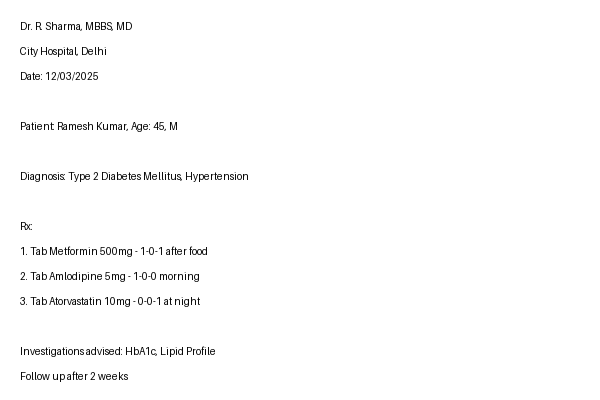

In [51]:
from PIL import Image, ImageDraw, ImageFont

def create_test_prescription_image():
    img = Image.new('RGB', (600, 400), color='white')
    draw = ImageDraw.Draw(img)
    
    text_lines = [
        "Dr. R. Sharma, MBBS, MD",
        "City Hospital, Delhi",
        "Date: 12/03/2025",
        "",
        "Patient: Ramesh Kumar, Age: 45, M",
        "",
        "Diagnosis: Type 2 Diabetes Mellitus, Hypertension",
        "",
        "Rx:",
        "1. Tab Metformin 500mg - 1-0-1 after food",
        "2. Tab Amlodipine 5mg - 1-0-0 morning",
        "3. Tab Atorvastatin 10mg - 0-0-1 at night",
        "",
        "Investigations advised: HbA1c, Lipid Profile",
        "Follow up after 2 weeks"
    ]
    
    y = 20
    for line in text_lines:
        draw.text((20, y), line, fill='black')
        y += 25
    
    img.save('test_prescription.png')
    return img

test_img = create_test_prescription_image()
test_img

In [52]:
import easyocr

reader = easyocr.Reader(['en'])  

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [53]:
ocr_results = reader.readtext('test_prescription.png')

for detection in ocr_results:
    bbox, text, confidence = detection
    print(f"{text} (confidence: {confidence:.2f})")
    

C:\Users\shifa\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Sharma MBBS MD (confidence: 0.71)
City Hcepital (confidence: 0.45)
Delhi (confidence: 1.00)
Date: 12/003/2025 (confidence: 0.42)
Patient Ramesh Kumar; Pge: 45,M (confidence: 0.42)
Diagncsis (confidence: 0.77)
Type (confidence: 0.96)
Diabetes Mellitus Hypertension (confidence: 0.81)
Tab Metformin 500mg (confidence: 0.42)
after food (confidence: 0.46)
Tab Amlodipine 5mg (confidence: 0.64)
1-0-0 morning (confidence: 0.97)
Tab Atorvastatin 10mg (confidence: 0.37)
atnight (confidence: 1.00)
Investigationsadvised: HbAIc Lipid Profile (confidence: 0.64)
Follow upatter (confidence: 0.95)
ieeks (confidence: 0.63)


In [54]:
def combine_ocr_text(ocr_results):
    lines = [detection[1] for detection in ocr_results]  
    return "\n".join(lines)

raw_ocr_text = combine_ocr_text(ocr_results)
print(raw_ocr_text)

Sharma MBBS MD
City Hcepital
Delhi
Date: 12/003/2025
Patient Ramesh Kumar; Pge: 45,M
Diagncsis
Type
Diabetes Mellitus Hypertension
Tab Metformin 500mg
after food
Tab Amlodipine 5mg
1-0-0 morning
Tab Atorvastatin 10mg
atnight
Investigationsadvised: HbAIc Lipid Profile
Follow upatter
ieeks


In [55]:
ocr_extraction_result = extract_document_data(raw_ocr_text)
print(ocr_extraction_result)

{"diagnosis":["Diabetes Mellitus","Hypertension"],"medications":[{"name":"Metformin","dosage":"500mg","frequency":"after food"},{"name":"Amlodipine","dosage":"5mg","frequency":"1-0-0 morning"},{"name":"Atorvastatin","dosage":"10mg","frequency":"at night"}],"investigations":["HbA1c","Lipid Profile"],"date":"12/003/2025","doctor_name":"Sharma MBBS MD"}


In [56]:
parsed_ocr_data = parse_extracted_data(ocr_extraction_result)
print(parsed_ocr_data)
print(type(parsed_ocr_data))

{'diagnosis': ['Diabetes Mellitus', 'Hypertension'], 'medications': [{'name': 'Metformin', 'dosage': '500mg', 'frequency': 'after food'}, {'name': 'Amlodipine', 'dosage': '5mg', 'frequency': '1-0-0 morning'}, {'name': 'Atorvastatin', 'dosage': '10mg', 'frequency': 'at night'}], 'investigations': ['HbA1c', 'Lipid Profile'], 'date': '12/003/2025', 'doctor_name': 'Sharma MBBS MD'}
<class 'dict'>


# Summary Generator

In [57]:
def generate_clinical_summary(conversation_transcript, document_data):
    
    transcript_text = "\n".join([f"Q: {item['question']}\nA: {item['answer']}" for item in conversation_transcript])
    
    doc_text = f"""
                Diagnosis (from prior records): {document_data.get('diagnosis', [])}
                Medications (from prior records): {document_data.get('medications', [])}
                Investigations (from prior records): {document_data.get('investigations', [])}
                Document date: {document_data.get('date', 'N/A')}
                """
    if document_data:
        doc_text = f"""Diagnosis (from prior records): {document_data.get('diagnosis', [])}
                Medications (from prior records): {document_data.get('medications', [])}
                Investigations (from prior records): {document_data.get('investigations', [])}
                Document date: {document_data.get('date', 'N/A')}"""
    else:
        doc_text = "No prior documents provided."
    
    prompt = f"""You are helping generate a clinical history summary for a doctor, 
          based on a patient intake conversation and their prior medical documents.

            CONVERSATION TRANSCRIPT:
            {transcript_text}
            
            PRIOR MEDICAL DOCUMENTS:
            {doc_text}
            
            Generate a structured clinical summary in EXACTLY this format:
            
            Chief Complaint:
            [one line summary]
            
            History of Present Illness:
            [summarize the SOCRATES-style details from the conversation]
            
            Past Medical/Surgical History:
            [from conversation]
            
            Drug & Allergy History:
            [combine conversation answers AND prior medications from documents]
            
            Family History:
            [from conversation]
            
            Personal History:
            [from conversation]
            
            Review of Systems:
            [from conversation]
            
            Prior Investigations Summary:
            [from documents, if any]
            
            Keep it concise and professional, in the tone a doctor would write in a patient chart. 
            Do not add any information not present in the transcript or documents."""

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    
    return response.choices[0].message.content.strip()
    

In [58]:
summary = generate_clinical_summary(final_state["transcript"], parsed_ocr_data)
print(summary)

Chief Complaint:
Sharp, constant central chest pain rated 6/10 with associated nausea.

History of Present Illness:
- **Site:** Center of chest  
- **Onset:** Sudden  
- **Character:** Sharp  
- **Radiation:** None  
- **Associated symptoms:** Nausea (no sweating, breathlessness)  
- **Timing:** Constant  
- **Exacerbating/Relieving factors:** None reported  
- **Severity:** 6/10

Past Medical/Surgical History:
- Diabetes Mellitus (known)  
- Hypertension (known)  
- No prior surgeries or hospitalizations.

Drug & Allergy History:
- **Current medications:** None reported by patient.  
- **Prior medications (recorded):** Metformin 500 mg after food; Amlodipine 5 mg once daily in the morning; Atorvastatin 10 mg at night.  
- **Allergies:** No known drug, food, or substance allergies; no prior adverse drug reactions.

Family History:
- No family history of diabetes, hypertension, heart disease, cancer, or similar chest complaints.

Personal History:
- Non‑smoker, no tobacco use.  
- No al